# 图像分类

**Q**: 结合行文
- 目前要解决的问题是什么？

## 数据生成

**Q**: 结合行文
- 问题的具体定义是什么？

**Q**: 结合代码
- 数据的规模是什么样的？
- 图像的的像素情况？

**Q**: 回答问题
- 灰度图像是如何表示的？
- RGB图像是如何表示的？

**Q**: 结合代码
- `stack`和`sum`在`axis`处理上有什么不同？
- 如何计算灰度？

In [1]:
# 引入

# 数据生成
from data_generation.image_classification import generate_dataset
# 绘图函数
from plots.chapter4 import *

# 科学计算
import numpy as np

(300, 1, 5, 5) (300,)
[[  0   0 255   0   0]
 [  0   0 255   0   0]
 [  0   0 255   0   0]
 [  0   0 255   0   0]
 [  0   0 255   0   0]] 0


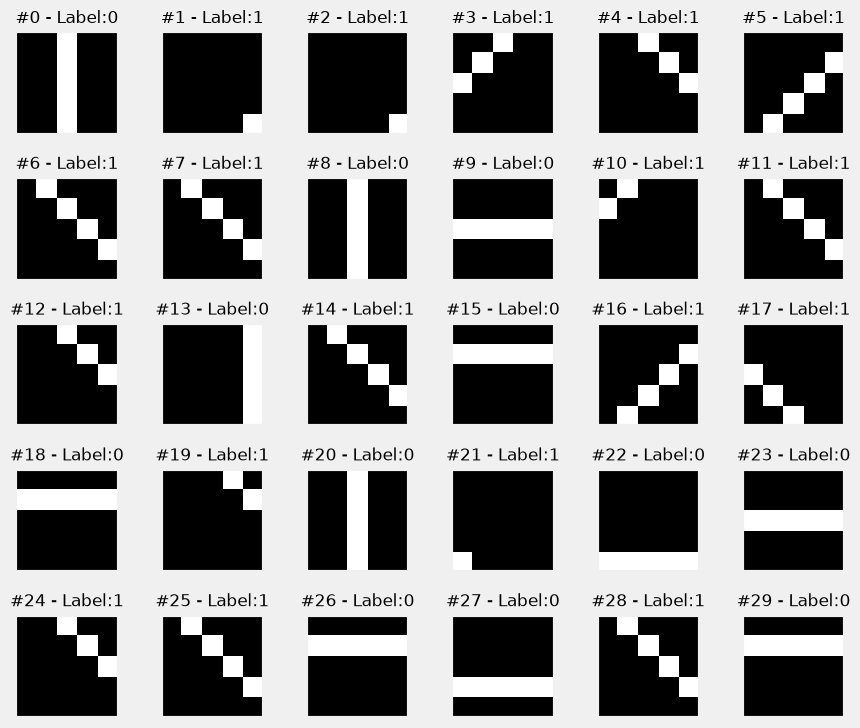

In [2]:
# 程序4-1: 数据生成

images, labels = generate_dataset(img_size=5, n_images=300, binary=True, seed=13)

# 数据集信息
print(images.shape,labels.shape)

# 图片的像素矩阵,标签
print(images[0][0][:],labels[0]) 

# 可视化图片和标签
fig = plot_images(images, labels, n_plot=30)

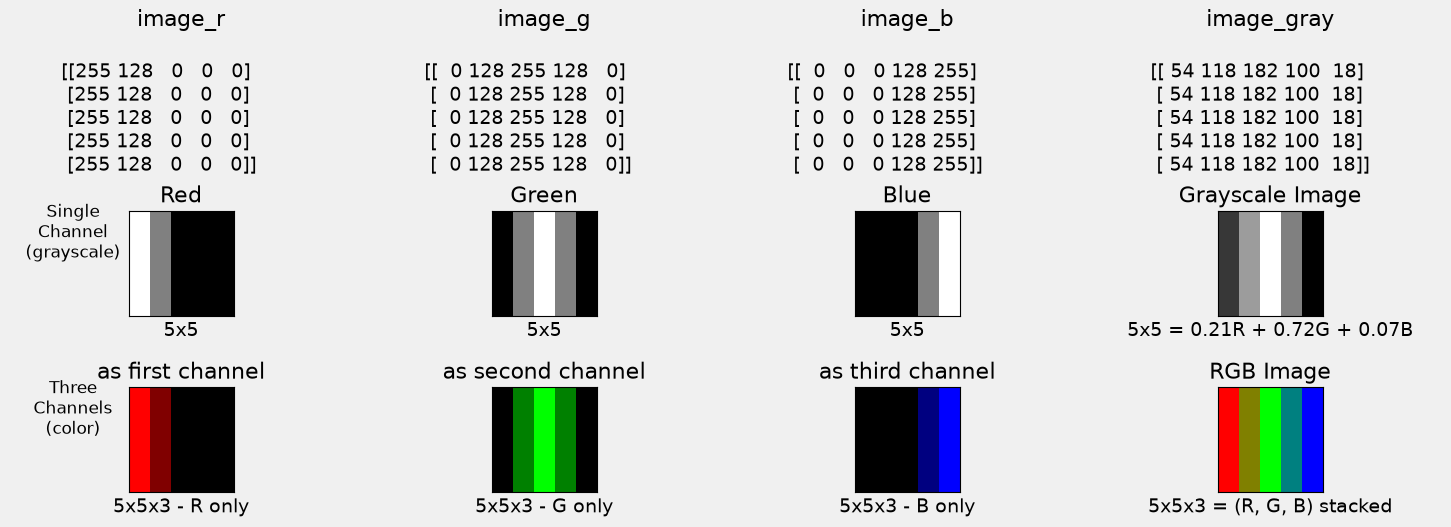

In [3]:
# 程序4-2: 像素的表示

# 生成各通道数据
image_r  = np.zeros((5, 5), dtype=np.uint8)
image_r[:, 0] = 255
image_r[:, 1] = 128

image_g = np.zeros((5, 5), dtype=np.uint8)
image_g[:, 1] = 128
image_g[:, 2] = 255
image_g[:, 3] = 128

image_b = np.zeros((5, 5), dtype=np.uint8)
image_b[:, 3] = 128
image_b[:, 4] = 255


# 计算灰度
image_gray = .2126*image_r + .7152*image_g + .0722*image_b

# 堆叠张量
image_rgb = np.stack([image_r, image_g, image_b], axis=2)

# 可视化结果
fig = image_channels(image_r, image_g, image_b, image_rgb, image_gray, rows=(0, 1,2))

In [6]:
# 程序4-3: sum和stack在axis参数上的对比
# 核心区别:
#   - sum:  沿指定轴求和,缩减维度(该轴被消除)
#   - stack:沿指定轴堆叠,增加维度(插入新轴)

foo_1 = np.array([
    [[1,2,3],[4,5,6],[7,8,9]],
    [[-1,-2,-3],[-4,-5,-6],[-7,-8,-9]]])

print("原始数组形状:", foo_1.shape)  # (2, 3, 3): 2个3×3矩阵

# ==================== sum: 沿指定轴求和(降维) ====================
# axis=0 → 将第0维(2个矩阵)对应位置相加,结果形状:(3,3)
print("\n=== sum axis=0 | 形状:", np.sum(foo_1, axis=0).shape, "===")
print(np.sum(foo_1, axis=0))

# axis=1 → 将第1维(每行3个元素)相加,结果形状:(2,3)
print("\n=== sum axis=1 | 形状:", np.sum(foo_1, axis=1).shape, "===")
print(np.sum(foo_1, axis=1))

# axis=2 → 将第2维(每列3个元素)相加,结果形状:(2,3)
print("\n=== sum axis=2 | 形状:", np.sum(foo_1, axis=2).shape, "===")
print(np.sum(foo_1, axis=2))

# ==================== stack: 沿指定轴堆叠(增维) ====================
# 将原数组拆成两个(3,3)矩阵,演示在不同axis位置插入新维度
a = foo_1[0]  # shape (3,3) — 正数矩阵
b = foo_1[1]  # shape (3,3) — 负数矩阵

# axis=0 → 在最外层堆叠,结果形状:(2,3,3) — 第0维区分a和b
print("\n=== stack [a,b] axis=0 | 形状:", np.stack([a, b], axis=0).shape, "===")
print(np.stack([a, b], axis=0))

# axis=1 → 在第1维堆叠,结果形状:(3,2,3) — 每行中,[0]来自a,[1]来自b
print("\n=== stack [a,b] axis=1 | 形状:", np.stack([a, b], axis=1).shape, "===")
print(np.stack([a, b], axis=1))

# axis=2 → 在第2维堆叠,结果形状:(3,3,2) — 每个元素位置上,[0]来自a,[1]来自b
print("\n=== stack [a,b] axis=2 | 形状:", np.stack([a, b], axis=2).shape, "===")
print(np.stack([a, b], axis=2))

原始数组形状: (2, 3, 3)

=== sum axis=0 | 形状: (3, 3) ===
[[0 0 0]
 [0 0 0]
 [0 0 0]]

=== sum axis=1 | 形状: (2, 3) ===
[[ 12  15  18]
 [-12 -15 -18]]

=== sum axis=2 | 形状: (2, 3) ===
[[  6  15  24]
 [ -6 -15 -24]]

=== stack [a,b] axis=0 | 形状: (2, 3, 3) ===
[[[ 1  2  3]
  [ 4  5  6]
  [ 7  8  9]]

 [[-1 -2 -3]
  [-4 -5 -6]
  [-7 -8 -9]]]

=== stack [a,b] axis=1 | 形状: (3, 2, 3) ===
[[[ 1  2  3]
  [-1 -2 -3]]

 [[ 4  5  6]
  [-4 -5 -6]]

 [[ 7  8  9]
  [-7 -8 -9]]]

=== stack [a,b] axis=2 | 形状: (3, 3, 2) ===
[[[ 1 -1]
  [ 2 -2]
  [ 3 -3]]

 [[ 4 -4]
  [ 5 -5]
  [ 6 -6]]

 [[ 7 -7]
  [ 8 -8]
  [ 9 -9]]]
